# DataAnalytics-L2-Task3-Fraud Detection

## Objective

Build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset, with a focus on handling class imbalance and evaluating fraud detection performance using appropriate classification metrics.

## Task Overview

This project focuses on detecting fraudulent financial transactions using machine learning.

The main challenges addressed in this task are:

- Understanding the severe class imbalance between fraudulent and legitimate transactions.
- Performing exploratory data analysis (EDA) on transaction amounts and transaction times.
- Applying an appropriate class imbalance handling technique.
- Training and comparing multiple machine learning models.
- Evaluating models using Precision, Recall, F1-Score, and AUC-ROC rather than relying only on accuracy.
- Identifying important features associated with fraudulent transactions.
- Discussing how the fraud detection system could be scaled to handle high transaction volumes.

## Dataset Information

The dataset used in this project is the Credit Card Fraud Detection dataset.

It contains credit card transactions made by European cardholders. The dataset contains anonymized numerical features along with transaction time, transaction amount, and a binary target variable indicating whether a transaction is fraudulent.

The target variable is:

- `0` — Non-fraudulent transaction
- `1` — Fraudulent transaction

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# Class imbalance handling
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option("display.max_columns", None)

# Visualization settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Library Overview

The following libraries will be used throughout the project:

- **pandas** and **NumPy** for data manipulation and numerical operations.
- **Matplotlib** and **Seaborn** for exploratory data analysis and visualization.
- **Scikit-learn** for data splitting, preprocessing, machine learning models, and evaluation metrics.
- **imbalanced-learn** for applying SMOTE oversampling to address class imbalance.

## Evaluation Approach

Because fraudulent transactions represent a very small proportion of the dataset, accuracy alone is not an appropriate measure of model performance.

For example, a model that predicts every transaction as non-fraudulent could achieve very high accuracy while failing to detect any fraudulent transactions.

Therefore, this project will primarily evaluate models using:

- **Precision** — proportion of transactions predicted as fraud that are actually fraudulent.
- **Recall** — proportion of actual fraudulent transactions that are successfully detected.
- **F1-Score** — harmonic mean of Precision and Recall.
- **AUC-ROC** — measures the model's ability to distinguish between fraudulent and legitimate transactions across different classification thresholds.

In [2]:
# Load the dataset
file_path = r"C:\Users\hp\Documents\Oasis Infobyte Tasks or Projects Documents\Task 7\Task 7 Documents\extracted csv\creditcard.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 284807
Number of columns: 31


## Dataset Overview

Before building the fraud detection models, we first inspect the structure, data types, and basic characteristics of the dataset.

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Display descriptive statistics for numerical columns
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0


## Class Distribution and Imbalance Analysis

The `Class` column is the target variable:

- `0` represents a legitimate transaction.
- `1` represents a fraudulent transaction.

Because fraud is expected to represent only a very small percentage of all transactions, it is important to quantify the class distribution before training any machine learning models.

In [8]:
# Count transactions in each class
class_counts = df["Class"].value_counts().sort_index()

print("Class distribution:")
print(class_counts)

print("\nLegitimate transactions (Class 0):", class_counts[0])
print("Fraudulent transactions (Class 1):", class_counts[1])

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Legitimate transactions (Class 0): 284315
Fraudulent transactions (Class 1): 492


In [9]:
# Calculate the percentage of each class
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Class percentages:")
print(class_percentages)

print(f"\nPercentage of legitimate transactions: {class_percentages[0]:.4f}%")
print(f"Percentage of fraudulent transactions: {class_percentages[1]:.4f}%")

Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Percentage of legitimate transactions: 99.8273%
Percentage of fraudulent transactions: 0.1727%


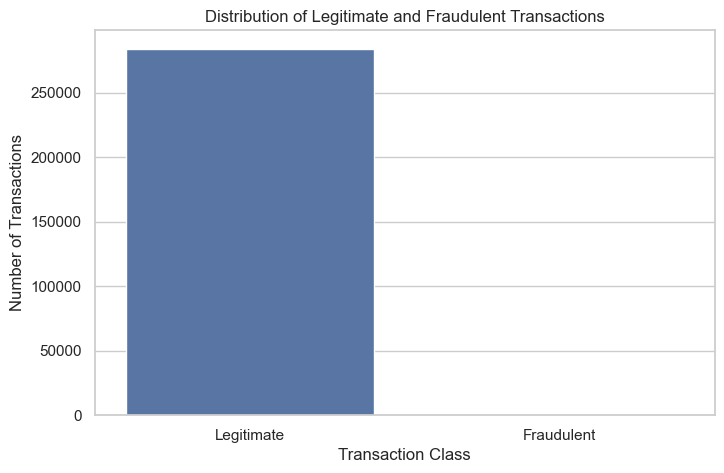

In [10]:
# Visualize class distribution
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.show()

### Class Imbalance Interpretation

The dataset is highly imbalanced. Approximately 99.83% of transactions are legitimate, while only about 0.17% are fraudulent.

This means that fraudulent transactions are extremely rare compared with legitimate transactions. Such severe class imbalance can cause a machine learning model to favor the majority class and potentially fail to identify fraudulent transactions.

Therefore, accuracy alone would not provide a reliable assessment of fraud detection performance. Techniques such as SMOTE and evaluation metrics including Precision, Recall, F1-Score, and AUC-ROC will be used later in the project to address and evaluate this problem appropriately.

## Exploratory Data Analysis (EDA)

Exploratory data analysis is performed to understand the characteristics of legitimate and fraudulent transactions, with particular attention to transaction amounts and transaction timing.

### Transaction Amount Distribution

The `Amount` column represents the monetary value of each transaction. We compare the distribution of transaction amounts between legitimate and fraudulent transactions to identify potential differences in transaction size.

In [11]:
# Compare transaction amount statistics for legitimate and fraudulent transactions

amount_summary = df.groupby("Class")["Amount"].describe()

amount_summary

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


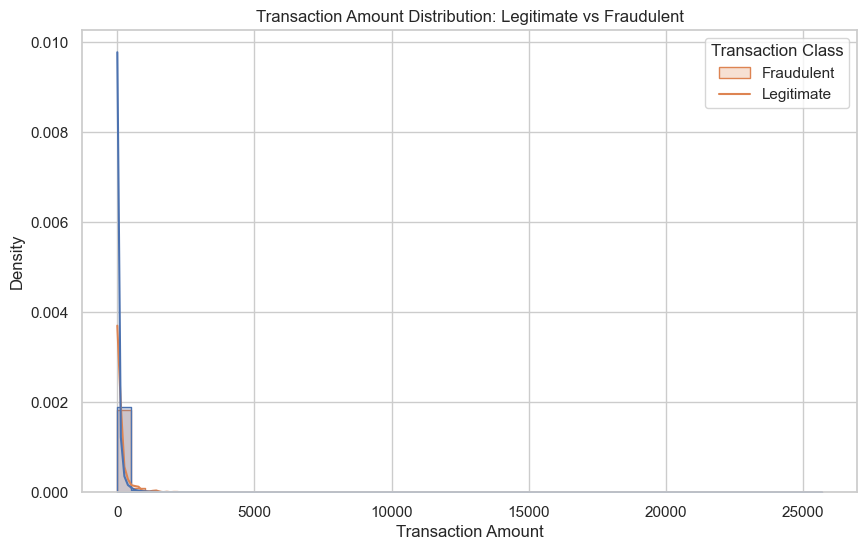

In [12]:
# Plot transaction amount distributions for legitimate and fraudulent transactions

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution: Legitimate vs Fraudulent")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend(title="Transaction Class", labels=["Fraudulent", "Legitimate"])

plt.show()

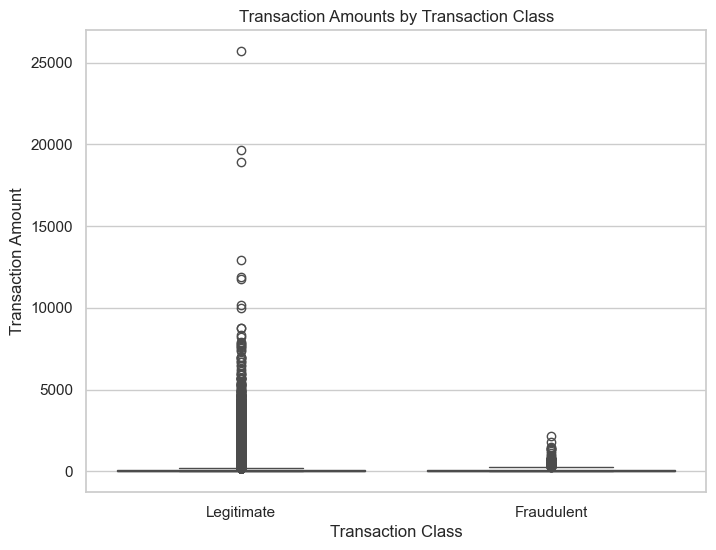

In [13]:
# Compare transaction amount distributions using a box plot

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amounts by Transaction Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.show()

### Transaction Amount Interpretation

The transaction amount distributions show how the monetary values of fraudulent transactions compare with legitimate transactions.

Because the dataset contains substantial variation and outliers in transaction amounts, the distributions should not be interpreted using a single statistic such as the mean alone. The median and overall distribution provide additional context.

The comparison helps determine whether fraudulent transactions tend to involve noticeably different transaction amounts from legitimate transactions.

### Fraud Patterns by Time of Day

The `Time` variable represents the number of seconds elapsed since the first transaction in the dataset. To investigate whether fraudulent activity varies throughout the day, we convert the elapsed time into an approximate hour of the day.

In [14]:
# Convert elapsed time in seconds into an approximate hour of the day

df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

# Display the first few calculated values
df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0


In [15]:
# Count fraudulent transactions by hour

fraud_by_hour = (
    df[df["Class"] == 1]
    .groupby("Hour")
    .size()
    .reindex(range(24), fill_value=0)
)

fraud_by_hour

Hour
0      6
1     10
2     57
3     17
4     23
5     11
6      9
7     23
8      9
9     16
10     8
11    53
12    17
13    17
14    23
15    26
16    22
17    29
18    33
19    19
20    18
21    16
22     9
23    21
dtype: int64

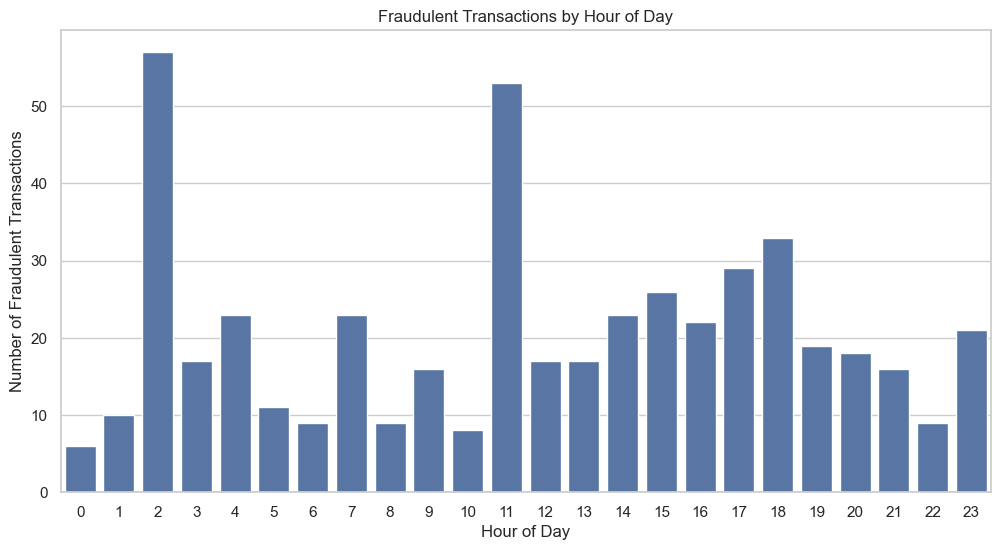

In [16]:
# Plot the number of fraudulent transactions by hour

plt.figure(figsize=(12, 6))

sns.barplot(
    x=fraud_by_hour.index,
    y=fraud_by_hour.values
)

plt.title("Fraudulent Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")
plt.xticks(range(24))

plt.show()

In [17]:
# Calculate total transactions and fraudulent transactions by hour

hourly_summary = df.groupby("Hour").agg(
    Total_Transactions=("Class", "size"),
    Fraudulent_Transactions=("Class", "sum")
)

# Calculate fraud percentage for each hour
hourly_summary["Fraud_Rate_Percent"] = (
    hourly_summary["Fraudulent_Transactions"]
    / hourly_summary["Total_Transactions"]
) * 100

hourly_summary

,Total_Transactions,Fraudulent_Transactions,Fraud_Rate_Percent
Hour,,,
0,7695,6,0.077973
1,4220,10,0.236967
2,3328,57,1.712740
3,3492,17,0.486827
4,2209,23,1.041195
5,2990,11,0.367893
6,4101,9,0.219459
7,7243,23,0.317548
8,10276,9,0.087583


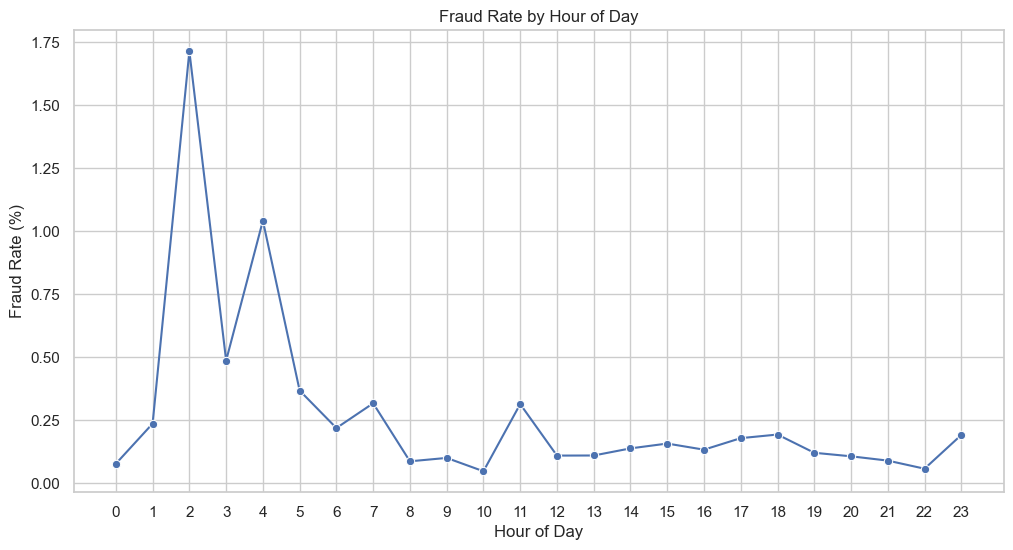

In [18]:
# Plot fraud rate by hour of day

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_summary,
    x=hourly_summary.index,
    y="Fraud_Rate_Percent",
    marker="o"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

### Time-of-Day Interpretation

The hourly analysis provides two complementary views of fraudulent activity:

1. The number of fraudulent transactions occurring during each hour.
2. The fraud rate, which represents the percentage of transactions that are fraudulent during each hour.

The fraud rate is particularly useful because the total number of transactions varies across different hours. Therefore, an hour with more fraud cases does not necessarily have a higher likelihood of fraud.

These patterns can help identify periods of increased fraudulent activity and may be useful when designing fraud monitoring and detection systems.

## Why Accuracy Is Misleading for Fraud Detection

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions.

In such a situation, accuracy can be misleading. For example, a model that predicts every transaction as legitimate could achieve very high accuracy because legitimate transactions make up almost the entire dataset. However, such a model would fail to detect fraudulent transactions.

For fraud detection, correctly identifying fraudulent transactions is particularly important. Therefore, this project will focus on Precision, Recall, F1-Score, and AUC-ROC rather than relying on accuracy alone.

Recall is especially important because it measures the proportion of actual fraudulent transactions that the model successfully identifies.

## Feature and Target Separation

The `Class` column is the target variable, while the remaining relevant columns are used as predictors.

The `Hour` feature created during EDA will not be used directly in the machine learning models because it was created specifically for exploratory time-of-day analysis. The original `Time` variable will also be retained as part of the available transaction information.

In [19]:
# Separate features and target variable

X = df.drop(columns=["Class", "Hour"])
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (284807, 30)
Target vector shape: (284807,)


## Stratified Train/Test Split

The dataset is divided into training and testing sets using stratification.

Stratification ensures that the proportion of fraudulent and legitimate transactions remains approximately the same in both sets. This is particularly important for a highly imbalanced classification problem.

The test set will remain untouched during class-imbalance handling and model training so that it provides an unbiased evaluation of model performance.

In [20]:
# Perform a stratified train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (227845, 30)
Testing set shape: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [21]:
# Calculate class percentages in the training set

train_class_distribution = y_train.value_counts(normalize=True) * 100

print("Training set class distribution:")
print(train_class_distribution)

Training set class distribution:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64


## Feature Scaling

Feature scaling is applied to standardize the numerical features.

The scaler is fitted only on the training data and then used to transform both the training and testing sets. This prevents information from the test set from influencing the preprocessing stage.

Scaling is particularly important for Logistic Regression because its optimization can be affected by differences in feature magnitudes.

In [22]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Testing data scaled successfully.")

Training data scaled successfully.
Testing data scaled successfully.


## Handling Class Imbalance with SMOTE

The training dataset contains a severe imbalance between legitimate and fraudulent transactions.

Synthetic Minority Over-sampling Technique (SMOTE) is used to address this imbalance. SMOTE generates synthetic examples of the minority class rather than simply duplicating existing fraudulent transactions.

SMOTE is applied only to the training data. The testing data is intentionally left unchanged so that model performance is evaluated on the original class distribution.

Applying SMOTE before the train/test split could cause data leakage and result in overly optimistic evaluation results.

In [23]:
# Apply SMOTE only to the training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training set shape:", X_train_scaled.shape)
print("SMOTE training set shape:", X_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Original training set shape: (227845, 30)
SMOTE training set shape: (454902, 30)

Class distribution after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


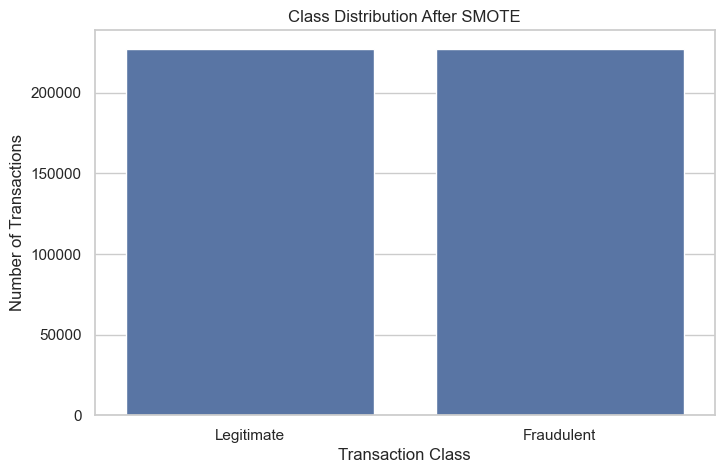

In [24]:
# Visualize class distribution after SMOTE

plt.figure(figsize=(8, 5))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.show()

## Verification of the Test Set

The test set has intentionally not been subjected to SMOTE. It retains the original highly imbalanced distribution.

This ensures that the final model evaluation represents a realistic fraud detection scenario.

In [25]:
# Verify that the test set retains the original class distribution

print("Test set class distribution:")
print(y_test.value_counts())

print("\nTest set class percentages:")
print((y_test.value_counts(normalize=True) * 100))

Test set class distribution:
Class
0    56864
1       98
Name: count, dtype: int64

Test set class percentages:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


## Model 1 — Logistic Regression

Logistic Regression is used as the first baseline classification model. It is a suitable model for binary classification and provides interpretable coefficients that can later be examined to understand feature influence.

The model is trained using the SMOTE-balanced training data and evaluated on the original, untouched test set.

In [26]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Model 2 — Random Forest

Random Forest is used as the second classification model. It is an ensemble learning method that combines multiple decision trees and can capture nonlinear relationships between features.

Because the dataset is highly imbalanced, the Random Forest model uses `class_weight="balanced"` during training. This automatically assigns greater importance to the minority fraud class without requiring the Random Forest model to be trained on the SMOTE-expanded dataset.

The Random Forest model is trained using the original scaled training data and evaluated on the untouched test set.

In [27]:
# Train a lightweight Random Forest model

# Use the original training data rather than the SMOTE-expanded data
random_forest_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

random_forest_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")

Training Random Forest...
Random Forest model trained successfully.


## Model Predictions

Both models are evaluated using the original test dataset. The test data has not been oversampled, allowing us to evaluate the models under the original class distribution.

In [28]:
# Generate class predictions

y_pred_logistic = logistic_model.predict(X_test_scaled)
y_pred_rf = random_forest_model.predict(X_test_scaled)

# Generate probability predictions for AUC-ROC
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## Logistic Regression Evaluation

The Logistic Regression model is evaluated using Precision, Recall, F1-Score, and AUC-ROC.

These metrics are more informative than accuracy for this highly imbalanced fraud detection problem.

In [29]:
# Calculate Logistic Regression evaluation metrics

logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Performance")
print("-" * 35)
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1-Score  : {logistic_f1:.4f}")
print(f"AUC-ROC   : {logistic_auc:.4f}")

Logistic Regression Performance
-----------------------------------
Precision : 0.0578
Recall    : 0.9184
F1-Score  : 0.1088
AUC-ROC   : 0.9708


In [30]:
# Display detailed classification report

print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Legitimate", "Fraudulent"]
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
  Fraudulent       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



## Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic Regression so that the two models can be compared fairly.

In [31]:
# Calculate Random Forest evaluation metrics

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-" * 30)
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")
print(f"AUC-ROC   : {rf_auc:.4f}")

Random Forest Performance
------------------------------
Precision : 0.8041
Recall    : 0.7959
F1-Score  : 0.8000
AUC-ROC   : 0.9609


In [32]:
# Display detailed classification report

print("Random Forest Classification Report")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Legitimate", "Fraudulent"]
))

Random Forest Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.80      0.80      0.80        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## Model Performance Comparison

The performance of Logistic Regression and Random Forest is compared using Precision, Recall, F1-Score, and AUC-ROC.

For fraud detection, Recall is particularly important because missing an actual fraudulent transaction can have significant consequences. However, Precision must also be considered because excessive false positives can cause legitimate transactions to be incorrectly flagged as fraudulent.

In [33]:
# Create a comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1
    ],
    "AUC-ROC": [
        logistic_auc,
        rf_auc
    ]
})

model_comparison

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.057803,0.918367,0.108761,0.970843
1,Random Forest,0.804124,0.795918,0.800000,0.960897


## Recall vs Precision in Fraud Detection

Recall and Precision represent different aspects of fraud detection performance.

**Recall** measures the proportion of actual fraudulent transactions that are successfully detected. A higher Recall means fewer fraudulent transactions are missed.

**Precision** measures the proportion of transactions classified as fraudulent that are actually fraudulent. A higher Precision means fewer legitimate transactions are incorrectly flagged.

In a fraud detection system, Recall is often particularly important because failing to detect a fraudulent transaction can result in financial loss. However, maximizing Recall without considering Precision can generate a large number of false positives and unnecessarily block legitimate transactions.

Therefore, the preferred model should provide an appropriate balance between Recall and Precision rather than optimizing only one metric.

## AUC-ROC Curve Comparison

The AUC-ROC curve illustrates the ability of each model to distinguish between fraudulent and legitimate transactions across different classification thresholds.

The Area Under the Curve (AUC) provides a single measure of the model's overall discrimination ability. A higher AUC indicates better separation between the two classes.

In [40]:
# Calculate predicted probabilities for both models

y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve values
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

print("ROC curve values calculated successfully.")

ROC curve values calculated successfully.


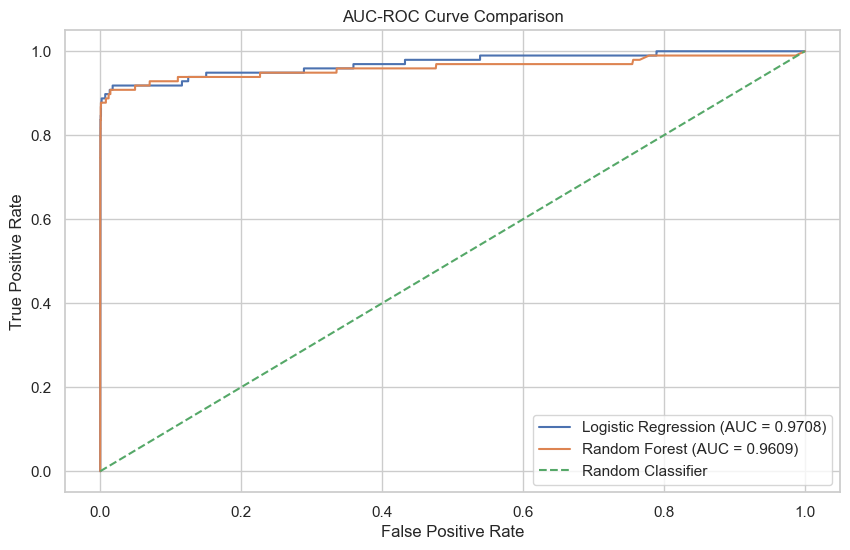

In [41]:
# Plot ROC curves for both models

plt.figure(figsize=(10, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("AUC-ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### AUC-ROC Interpretation

The ROC curves compare the ability of Logistic Regression and Random Forest to distinguish fraudulent transactions from legitimate transactions.

The model with the higher AUC-ROC generally demonstrates better overall discriminatory ability. However, AUC-ROC should not be considered in isolation because fraud detection also requires careful consideration of Precision and Recall, particularly when the positive class is extremely rare.

## Confusion Matrix Analysis

A confusion matrix shows the number of true positives, true negatives, false positives, and false negatives produced by each model.

For fraud detection:

- **True Positive (TP):** Fraudulent transaction correctly identified as fraud.
- **True Negative (TN):** Legitimate transaction correctly identified as legitimate.
- **False Positive (FP):** Legitimate transaction incorrectly classified as fraud.
- **False Negative (FN):** Fraudulent transaction incorrectly classified as legitimate.

False negatives are particularly important because they represent fraudulent transactions that the system failed to detect.

In [36]:
# Calculate confusion matrices

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

Logistic Regression Confusion Matrix:
[[55397  1467]
 [    8    90]]

Random Forest Confusion Matrix:
[[56845    19]
 [   20    78]]


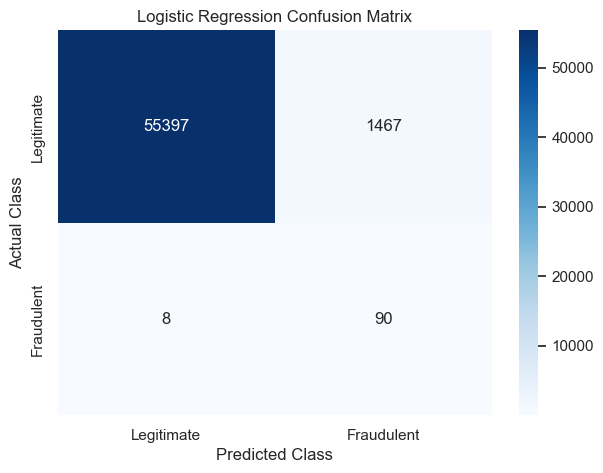

In [38]:
# Visualize Logistic Regression confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

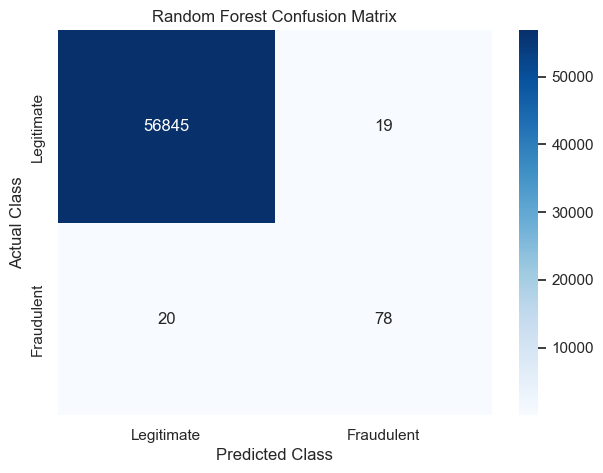

In [39]:
# Visualize Random Forest confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## Feature Importance Analysis

Understanding which features contribute most to fraud predictions can provide useful insight into the characteristics of fraudulent transactions.

For Logistic Regression, the magnitude of the model coefficients indicates the direction and relative strength of the relationship between each feature and the predicted probability of fraud.

For Random Forest, feature importance values indicate how much each feature contributes to the model's predictive decisions.

In [42]:
# Extract Logistic Regression coefficients

logistic_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Calculate absolute coefficient magnitude
logistic_coefficients["Absolute_Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

# Sort by absolute coefficient magnitude
logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

logistic_coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
29,Amount,2.270462,2.270462
1,V1,1.815385,1.815385
10,V10,-1.713830,1.713830
14,V14,-1.629045,1.629045
4,V4,1.584424,1.584424
5,V5,1.294254,1.294254
17,V17,-1.149217,1.149217
12,V12,-1.086633,1.086633
16,V16,-1.077560,1.077560
20,V20,-1.008791,1.008791


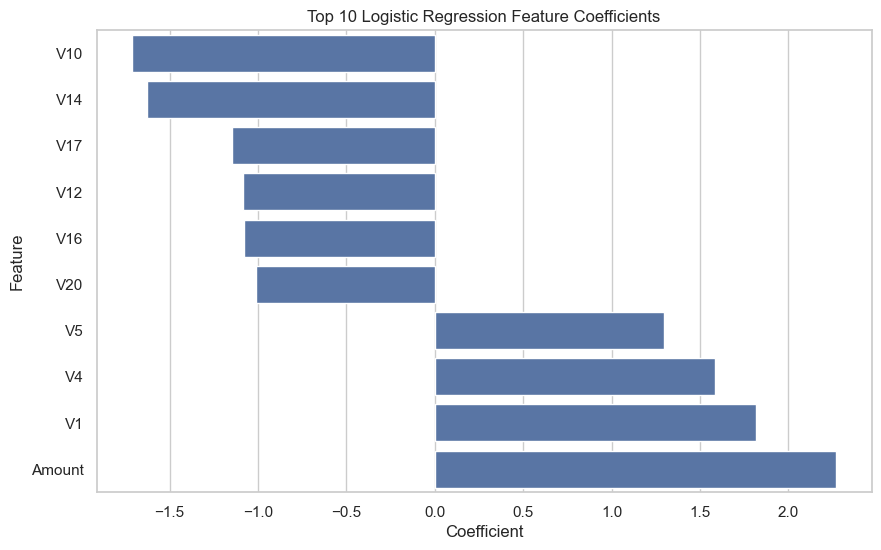

In [43]:
# Plot the 10 most influential Logistic Regression features

top_logistic_features = logistic_coefficients.head(10).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_logistic_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [44]:
# Extract Random Forest feature importance

rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_feature_importance.head(10)

,Feature,Importance
14,V14,0.305793
17,V17,0.157459
12,V12,0.084072
4,V4,0.072212
3,V3,0.061377
10,V10,0.060722
16,V16,0.031934
2,V2,0.028727
9,V9,0.025107
11,V11,0.017718


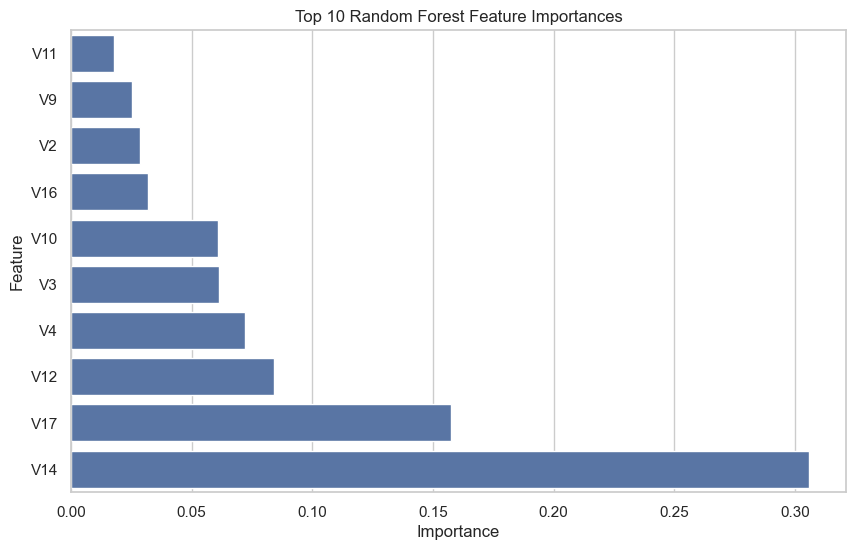

In [45]:
# Plot the 10 most important Random Forest features

top_rf_features = rf_feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance Interpretation

The feature importance results show that some anonymized transaction features contribute more strongly to fraud prediction than others.

For Logistic Regression, features with larger absolute coefficients have a stronger influence on the model's predictions. Positive coefficients increase the predicted likelihood of fraud, while negative coefficients decrease it.

For Random Forest, higher feature-importance values indicate that the feature contributes more strongly to the model's decision-making process.

Because the `V1`–`V28` variables are anonymized PCA-transformed features, their individual business meaning cannot be directly interpreted. However, their predictive importance can still be evaluated statistically.

## Scalability: Handling 1 Million Transactions per Hour

A real-world fraud detection system may need to process millions of transactions within a short period of time. A system handling 1 million transactions per hour would need to process approximately 278 transactions per second on average.

To scale such a system, the machine learning model would need to be integrated into a high-throughput data processing and serving architecture.

Potential approaches include:

- Deploying the trained model as a low-latency prediction service.
- Using distributed streaming systems such as Apache Kafka for continuous transaction ingestion.
- Using scalable processing frameworks such as Apache Spark for large-scale data processing.
- Performing feature engineering efficiently and consistently between training and production.
- Using model-serving infrastructure capable of handling concurrent prediction requests.
- Monitoring prediction latency, model performance, data drift, and fraud detection rates.
- Periodically retraining the model using newly labeled transaction data.
- Using threshold optimization to balance fraud detection Recall against false-positive rates.

For extremely high transaction volumes, a real-time architecture could combine rule-based checks with machine learning predictions so that suspicious transactions can be prioritized for further investigation.

## Final Model Comparison

In [46]:
# Display the final model comparison

model_comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Random Forest,0.804124,0.795918,0.800000,0.960897
1,Logistic Regression,0.057803,0.918367,0.108761,0.970843


In [47]:
# Identify the best-performing model for each evaluation metric

best_precision_model = model_comparison.loc[
    model_comparison["Precision"].idxmax(), "Model"
]

best_recall_model = model_comparison.loc[
    model_comparison["Recall"].idxmax(), "Model"
]

best_f1_model = model_comparison.loc[
    model_comparison["F1-Score"].idxmax(), "Model"
]

best_auc_model = model_comparison.loc[
    model_comparison["AUC-ROC"].idxmax(), "Model"
]

print("Best Precision:", best_precision_model)
print("Best Recall:", best_recall_model)
print("Best F1-Score:", best_f1_model)
print("Best AUC-ROC:", best_auc_model)

Best Precision: Random Forest
Best Recall: Logistic Regression
Best F1-Score: Random Forest
Best AUC-ROC: Logistic Regression


In [48]:
model_comparison

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.057803,0.918367,0.108761,0.970843
1,Random Forest,0.804124,0.795918,0.800000,0.960897


In [49]:
logistic_coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
29,Amount,2.270462,2.270462
1,V1,1.815385,1.815385
10,V10,-1.713830,1.713830
14,V14,-1.629045,1.629045
4,V4,1.584424,1.584424
5,V5,1.294254,1.294254
17,V17,-1.149217,1.149217
12,V12,-1.086633,1.086633
16,V16,-1.077560,1.077560
20,V20,-1.008791,1.008791


In [50]:
rf_feature_importance.head(10)

,Feature,Importance
14,V14,0.305793
17,V17,0.157459
12,V12,0.084072
4,V4,0.072212
3,V3,0.061377
10,V10,0.060722
16,V16,0.031934
2,V2,0.028727
9,V9,0.025107
11,V11,0.017718


In [51]:
best_precision_model = model_comparison.loc[
    model_comparison["Precision"].idxmax(), "Model"
]

best_recall_model = model_comparison.loc[
    model_comparison["Recall"].idxmax(), "Model"
]

best_f1_model = model_comparison.loc[
    model_comparison["F1-Score"].idxmax(), "Model"
]

best_auc_model = model_comparison.loc[
    model_comparison["AUC-ROC"].idxmax(), "Model"
]

print("Best Precision:", best_precision_model)
print("Best Recall:", best_recall_model)
print("Best F1-Score:", best_f1_model)
print("Best AUC-ROC:", best_auc_model)

Best Precision: Random Forest
Best Recall: Logistic Regression
Best F1-Score: Random Forest
Best AUC-ROC: Logistic Regression


In [52]:
cm_logistic

array([[55397,  1467],
       [    8,    90]])

In [53]:
cm_rf

array([[56845,    19],
       [   20,    78]])

In [54]:
hourly_summary

,Total_Transactions,Fraudulent_Transactions,Fraud_Rate_Percent
Hour,,,
0,7695,6,0.077973
1,4220,10,0.236967
2,3328,57,1.712740
3,3492,17,0.486827
4,2209,23,1.041195
5,2990,11,0.367893
6,4101,9,0.219459
7,7243,23,0.317548
8,10276,9,0.087583


## Conclusion

This project developed a machine learning-based fraud detection system using a highly imbalanced credit card transaction dataset containing 284,807 transactions, of which only 492 were fraudulent.

Exploratory analysis showed that fraudulent transactions represented approximately 0.17% of all transactions, demonstrating the severe class imbalance in the dataset. Transaction amount distributions and time-of-day patterns were also examined. The highest observed fraud rate occurred around Hour 2, where approximately 1.71% of transactions were fraudulent.

To address the class imbalance problem, a stratified train-test split was performed and SMOTE was applied only to the training data. This prevented information from the test set from being introduced into the resampling process.

Two machine learning models were trained and evaluated: Logistic Regression and Random Forest. The models were assessed using Precision, Recall, F1-Score, and AUC-ROC rather than relying on accuracy alone.

Logistic Regression achieved a Precision of 0.0578, Recall of 0.9184, F1-Score of 0.1088, and AUC-ROC of 0.9708. It achieved the highest Recall and AUC-ROC, detecting 90 of the 98 fraudulent transactions in the test set. However, it generated 1,467 false positives, resulting in relatively low Precision.

Random Forest achieved a Precision of 0.8041, Recall of 0.7959, F1-Score of 0.8000, and AUC-ROC of 0.9609. Its confusion matrix showed only 19 false positives and 20 false negatives. Therefore, Random Forest provided a much stronger balance between detecting fraud and avoiding false alarms, and achieved the highest Precision and F1-Score.

Feature analysis showed that V14 was the most important feature in the Random Forest model, followed by V17, V12, V4, V3, and V10. In the Logistic Regression model, Amount had the largest absolute coefficient, followed by V1, V10, V14, and V4. Since V1–V28 are anonymized PCA-transformed variables, their underlying business meanings cannot be directly interpreted.

Overall, Random Forest provides the strongest balanced performance for this task because of its substantially higher Precision and F1-Score, while Logistic Regression may be preferable in situations where maximizing fraud detection Recall is the primary objective.

For deployment at a scale of approximately 1 million transactions per hour, the fraud detection system would require a scalable real-time architecture capable of processing roughly 278 transactions per second on average. Technologies such as streaming platforms, distributed processing, scalable model-serving infrastructure, efficient feature engineering, monitoring, and periodic model retraining could be used to support such a system.

The project demonstrates that effective fraud detection requires more than high overall accuracy. Handling class imbalance correctly and selecting appropriate evaluation metrics are essential for building a practical fraud detection system.